# Week 2 — Fluid Mechanics I: Forces on a Continuum and the Material Derivative

**OE 754 / 854 — Ocean Waves & Tides**

This week sets up the machinery we use for the rest of the semester: forces on a continuum, the Cauchy stress tensor, the Navier--Stokes equations, and the material derivative that connects the Eulerian and Lagrangian descriptions. The derivations are in the lecture notes; this notebook is visualizations. Eulerian $\partial u/\partial t$ against Lagrangian $Du/Dt$ is easier to see than to read about.

### Goals

1. Visualize the Eulerian vs. Lagrangian split with a synthetic converging-channel flow.
2. Compute $Du/Dt = \partial u/\partial t + (\mathbf u \cdot \nabla)u$ from a simple analytical flow and check it against the finite-difference Lagrangian rate.
3. Do a dimensional-consistency check on the continuity, momentum, and Bernoulli equations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import figure_style as fs

g = 9.81

## 1. Eulerian vs. Lagrangian: a converging channel

Take the steady 2D flow $u(x) = U_0 (1 + x/L)$ in a channel that narrows linearly, so the velocity goes from $U_0$ at $x = 0$ to $2U_0$ at $x = L$. (Continuity, plus steady and incompressible, gives this from a constant volumetric flux and a linear width taper.)

A fixed current meter at any point $x_0$ sees a constant velocity: $\partial u/\partial t = 0$. The flow is steady. But a drifter released at $x = 0$ accelerates as it moves downstream into faster water.

Both statements are true. They measure different things.

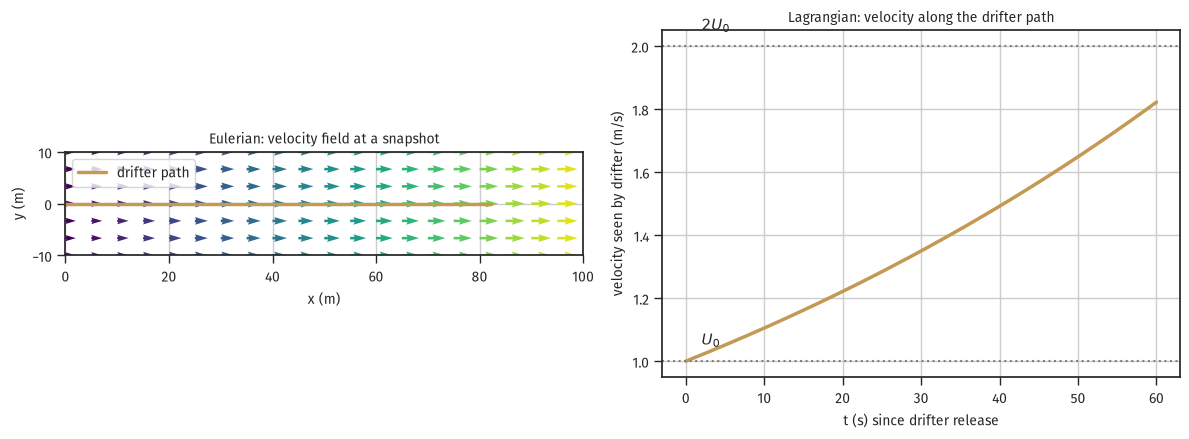

In [2]:
U0 = 1.0    # m/s at channel inlet
L = 100.0   # m, length of taper

def u_steady(x):
    return U0 * (1 + x / L)

# Eulerian: velocity field at one instant
x_field = np.linspace(0, L, 21)
y_field = np.linspace(-10, 10, 7)
X, Y = np.meshgrid(x_field, y_field)
U = u_steady(X)
V = np.zeros_like(U)

# Lagrangian: parcel released at x = 0, y = 0.
# dx/dt = u(x), x(0) = 0  ->  x(t) = L*(exp(U0*t/L) - 1)
t_track = np.linspace(0, 60, 200)
x_track = L * (np.exp(U0 * t_track / L) - 1)
u_track = u_steady(x_track)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.quiver(X, Y, U, V, U, cmap='viridis', scale=50)
ax1.plot(x_track[x_track < L], np.zeros_like(x_track[x_track < L]),
         '-', color=fs.color_list[3], lw=2.5, label='drifter path')
ax1.set_xlim(0, L)
ax1.set_ylim(-10, 10)
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_title('Eulerian: velocity field at a snapshot')
ax1.set_aspect('equal')
ax1.legend(loc='upper left')

# Velocity along the drifter path
ax2.plot(t_track, u_track, lw=2.5, color=fs.color_list[3])
ax2.set_xlabel('t (s) since drifter release')
ax2.set_ylabel('velocity seen by drifter (m/s)')
ax2.set_title('Lagrangian: velocity along the drifter path')
ax2.axhline(U0, ls=':', color='0.5', lw=1.5)
ax2.axhline(2*U0, ls=':', color='0.5', lw=1.5)
ax2.text(2, U0 + 0.05, r'$U_0$', fontsize=11)
ax2.text(2, 2*U0 + 0.05, r'$2U_0$', fontsize=11)

plt.tight_layout()
plt.show()

$\partial u/\partial t = 0$ at every fixed point, yet a parcel following the flow sees its velocity double in about a minute. That acceleration is the advective piece of the material derivative:

$$\frac{Du}{Dt} = \underbrace{\frac{\partial u}{\partial t}}_{\text{Eulerian rate}} + \underbrace{(\mathbf u \cdot \nabla) u}_{\text{advective}} = 0 + u\frac{du}{dx} = U_0(1 + x/L) \cdot \frac{U_0}{L}.$$

## 2. Verifying $Du/Dt$ numerically

Compute the advective term analytically, then compare with the finite-difference rate measured along the drifter trajectory. The two should agree to the $O(\Delta t^2)$ truncation error of the centered difference, which at this time step is parts per million.

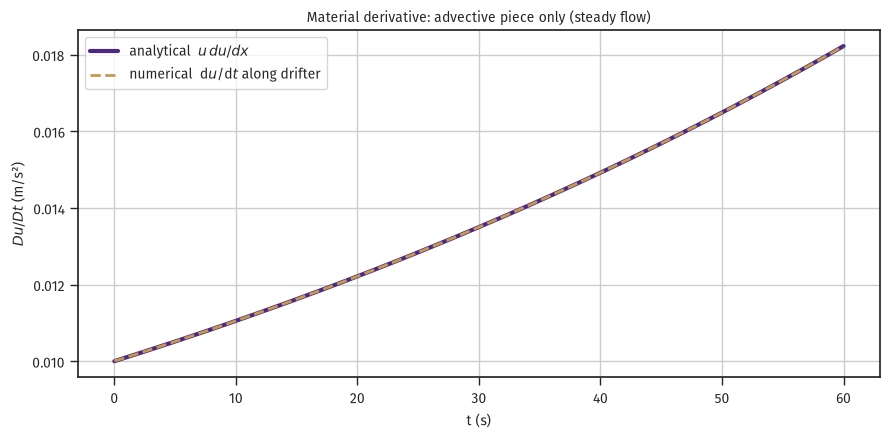

Time step dt = 0.3015 s
Max relative error in interior: 1.515e-06
Expected (dt/tau)²/6          : 1.515e-06


In [3]:
# Analytical Du/Dt = u du/dx = U0^2/L * (1 + x/L), m/s^2
DuDt_analytic = U0**2 / L * (1 + x_track / L)

# Numerical Du/Dt from the drifter velocity record, m/s^2
DuDt_numeric = np.gradient(u_track, t_track)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t_track, DuDt_analytic, lw=3, color=fs.color_list[0], label='analytical  $u\\,du/dx$')
ax.plot(t_track, DuDt_numeric,  '--', lw=2, color=fs.color_list[3],
        label='numerical  d$u$/d$t$ along drifter')
ax.set_xlabel('t (s)')
ax.set_ylabel(r'$Du/Dt$ (m/s²)')
ax.set_title(r'Material derivative: advective piece only (steady flow)')
ax.legend()
plt.tight_layout()
plt.show()

# Interior comparison; np.gradient is one-sided at the endpoints
interior = slice(5, -5)
rel_err = np.abs(DuDt_analytic[interior] - DuDt_numeric[interior]).max() / DuDt_analytic[interior].max()
dt = t_track[1] - t_track[0]
# Centered-difference truncation for u ~ exp(t/tau), tau = L/U0: (dt/tau)^2/6
print(f'Time step dt = {dt:.4f} s')
print(f'Max relative error in interior: {rel_err:.3e}')
print(f'Expected (dt/tau)²/6          : {(dt*U0/L)**2/6:.3e}')


The two lines lie on top of each other. There is nothing here past the chain rule, and the residual disagreement is the centered-difference truncation error, landing on the predicted $(\Delta t/\tau)^2/6 \sim 10^{-6}$.

## 3. Incompressibility as a flow property

The lecture notes make a point of this: **"incompressible" is a statement about the flow, not the fluid.** Water is slightly compressible (acoustic waves propagate through it), but in surface-wave flows $\nabla \cdot \mathbf u \approx 0$ holds to high accuracy, because wave speeds are tiny next to the speed of sound.

Check that on the converging-channel flow. In 2D with $u(x)$ only, continuity forces the channel width to taper. Pretend instead that the width is constant, and $\partial u/\partial x \ne 0$ implies $\nabla \cdot \mathbf u \ne 0$. Put a number on the violation:

In [4]:
# Continuity in 2D: du/dx + dv/dy = 0. For u(x) = U0(1 + x/L) this requires
# dv/dy = -U0/L, met by v(x,y) = -(U0/L)*y with no flux through a tapering wall.
# Dropping v leaves div u = du/dx = U0/L, a fractional compression rate of
# (1/rho) drho/dt = -U0/L. Density response scales as the squared Mach number.

U = 1.0       # m/s, typical flow speed
c_s = 1500.0  # m/s, acoustic speed in water
M = U / c_s
print(f'Mach number, 1 m/s ocean flow: M = {M:.2e}')
print(f'compressibility correction, M² = {M**2:.2e}')
print(f'density variation = {M**2*1e6:.2f} ppm')


Mach number, 1 m/s ocean flow: M = 6.67e-04
compressibility correction, M² = 4.44e-07
density variation = 0.44 ppm


## 4. Dimensional consistency check

Every equation in this course has to be dimensionally consistent. Most algebra errors you'll make break dimensional consistency. Habit starts now. Let's check a few of the equations we'll meet:

- **Continuity**: $\nabla \cdot \mathbf u = 0$. LHS units: (m/s) / m = 1/s. Zero has no units, so the equation reads "rate [1/s] = 0", which is fine.

- **Navier–Stokes momentum** (one term): $\rho\,Du/Dt = -\partial p/\partial x$. LHS: (kg/m³)(m/s²) = kg/(m²·s²) = Pa/m. RHS: (Pa)/m. ✓

- **Unsteady Bernoulli**: $-\partial\phi/\partial t + \tfrac12 |\mathbf u|^2 + P/\rho + gz = C(t)$. Each term is m²/s². Check a few:

In [5]:
import numpy as np

def units_check(name, expr_value, expected_dim_str):
    print(f'  {name:<40s}  numerical value: {expr_value:<12.3g}  expected: {expected_dim_str}')

# Scales for a moderate ocean wave: H = 2 m, T = 10 s, h = 50 m
H, T, h = 2.0, 10.0, 50.0
omega = 2*np.pi/T
k = omega**2 / g   # deep water
a = H/2
rho = 1025.0

# phi [m^2/s], eta [m], u [m/s]
phi_scale = g*a/omega                # gH/(2 omega), m^2/s
u_scale = omega * a                  # particle velocity amplitude, m/s
eta_scale = a

# Bernoulli terms at the surface, m^2/s^2
term_dphidt = phi_scale * omega                # [m^2/s * 1/s] = m^2/s^2
term_kinetic = 0.5 * u_scale**2                # [m^2/s^2]
term_gravity = g * eta_scale                   # [m/s^2 * m] = m^2/s^2
# P/rho: for an Airy wave P_dyn ~ rho g eta, so P/rho ~ g eta
term_pressure = g * eta_scale                  # [m^2/s^2]

print('Bernoulli-equation terms (units of m^2/s^2 for an H=2m, T=10s wave):\n')
units_check('∂φ/∂t',                  term_dphidt,  '~ 10  (m/s)^2')
units_check('½ |u|²',                 term_kinetic, '~ 1   (m/s)^2')
units_check('P / ρ  (dynamic)',       term_pressure,'~ 10  (m/s)^2')
units_check('g η  (at surface)',      term_gravity, '~ 10  (m/s)^2')

print()
print(f'ka = {k*a:.4f}')
print(f'½ka = {0.5*k*a:.4f}')
print(f'kinetic / gravity term ratio = {term_kinetic/term_gravity:.4f}')


Bernoulli-equation terms (units of m^2/s^2 for an H=2m, T=10s wave):

  ∂φ/∂t                                     numerical value: 9.81          expected: ~ 10  (m/s)^2
  ½ |u|²                                    numerical value: 0.197         expected: ~ 1   (m/s)^2
  P / ρ  (dynamic)                          numerical value: 9.81          expected: ~ 10  (m/s)^2
  g η  (at surface)                         numerical value: 9.81          expected: ~ 10  (m/s)^2

ka = 0.0402
½ka = 0.0201
kinetic / gravity term ratio = 0.0201


Those numbers are the scaling argument we use in Week 5: for a moderate wave the kinetic term $\tfrac12|\mathbf u|^2$ is smaller than $g\eta$ by a factor $\tfrac12 ka$. Here $ka \approx 0.040$, so the ratio is about $0.020$. Two percent. That is the justification for linearization, and it is an actual small number. The neglected term is $O(ka)$ relative to the ones we keep, not $O((ka)^2)$.

## 5. Exercises

1. Take a 2D unsteady flow like $u(x, t) = U_0 + a \sin(kx - \omega t)$ (a sinusoid riding on a mean current). Compute $Du/Dt$ analytically. Which of the three pieces (unsteady, mean advection, wave self-advection) dominate in the small-amplitude limit $a \ll U_0$? In the pure-wave limit $U_0 = 0$?

2. Rerun the converging-channel cells with a channel that diverges instead, $r(x) = r_0(1 + \alpha x)$. Does the sign of the advective acceleration flip? What happens to the pressure along the centerline, and what does that tell you about why diffusers stall and nozzles do not?

3. The dimensional check above compared term magnitudes for an $H = 2$ m, $T = 10$ s wave. Redo it for a $T = 2$ s wind chop of $H = 0.4$ m and for a $T = 12$ h tide of $H = 2$ m. Which of the three cases has the largest $ka$, and which the smallest? That ordering is why linear theory covers tides and swell equally well and struggles most with steep chop.

## Looking ahead

Week 3 finishes the fluid mechanics: continuity, the Reynolds transport theorem, circulation and Kelvin's theorem, the velocity potential and streamfunction, and Bernoulli. Week 4 then assembles the four equations (Laplace, BBC, KFSBC, DFSBC) that the rest of the course builds on.